In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')

df = pd.read_csv('data.csv', sep=';')
target = df['Target']

In [ ]:
n_rows, n_cols = df.shape
print(f"Rows    : {n_rows:,}")
print(f"Columns : {n_cols}  ({n_cols - 1} features + 1 target)")
df.head()

Rows    : 4,424
Columns : 37  (36 features + 1 target)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [18]:
print(df.dtypes.value_counts().to_string())
print()
df.info()

int64      29
float64     7
object      1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9 

In [19]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).query('missing_count > 0')

if missing.empty:
    print("No missing values found — dataset is complete.")
else:
    print(f"{len(missing)} columns have missing values:\n")
    display(missing.sort_values('missing_pct', ascending=False))


No missing values found — dataset is complete.


          count  percentage
Target                     
Graduate   2209        49.9
Dropout    1421        32.1
Enrolled    794        17.9


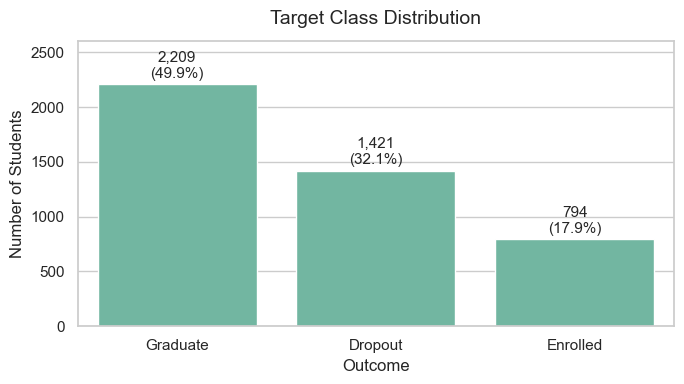

In [21]:
target_counts = df['Target'].value_counts()
target_pct = (target_counts / len(df) * 100).round(1)

print(pd.DataFrame({'count': target_counts, 'percentage': target_pct}).to_string())

fig, ax = plt.subplots(figsize=(7, 4))

bars = sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    order=['Graduate', 'Dropout', 'Enrolled'],
    ax=ax
)

for bar, label in zip(bars.patches, ['Graduate', 'Dropout', 'Enrolled']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{target_counts[label]:,}\n({target_pct[label]}%)",
        ha='center', va='bottom', fontsize=11
    )

ax.set_title('Target Class Distribution', fontsize=14, pad=12)
ax.set_xlabel('Outcome', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.set_ylim(0, target_counts.max() * 1.18)

plt.tight_layout()
plt.show()


# Grades By Outcome

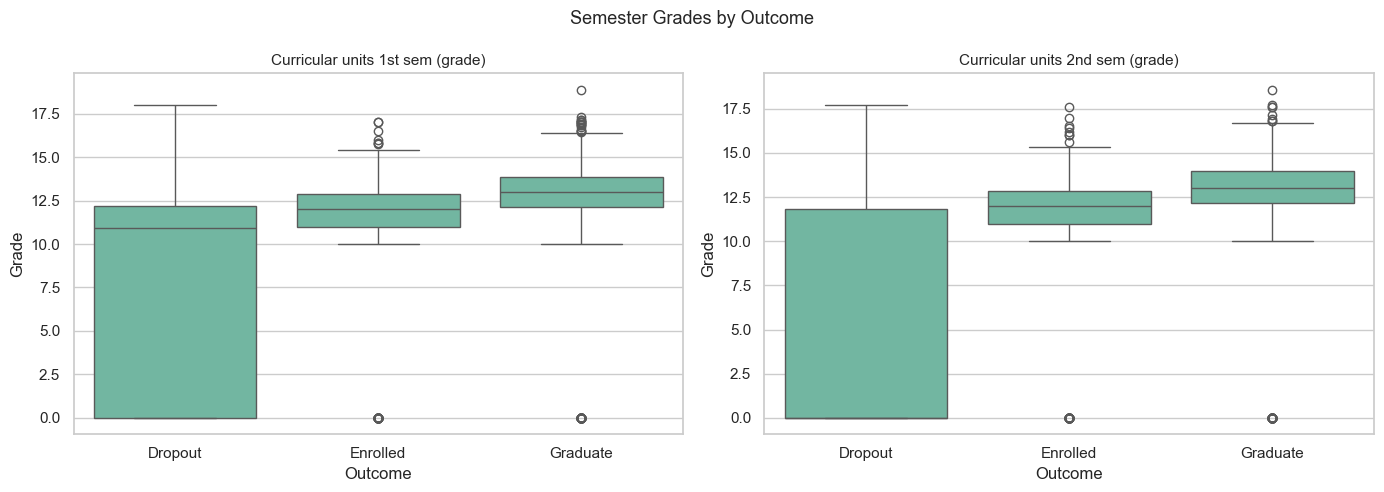

In [22]:
# Academic grade distributions split by outcome
grade_features = [
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, feat in enumerate(grade_features):
    sns.boxplot(data=df, x='Target', y=feat, ax=axes[i],
                order=['Dropout', 'Enrolled', 'Graduate'])
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Outcome')
    axes[i].set_ylabel('Grade')

plt.suptitle('Semester Grades by Outcome', fontsize=13)
plt.tight_layout()
plt.savefig('grades_by_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

### Enrolled vs approved units (the gap signal)

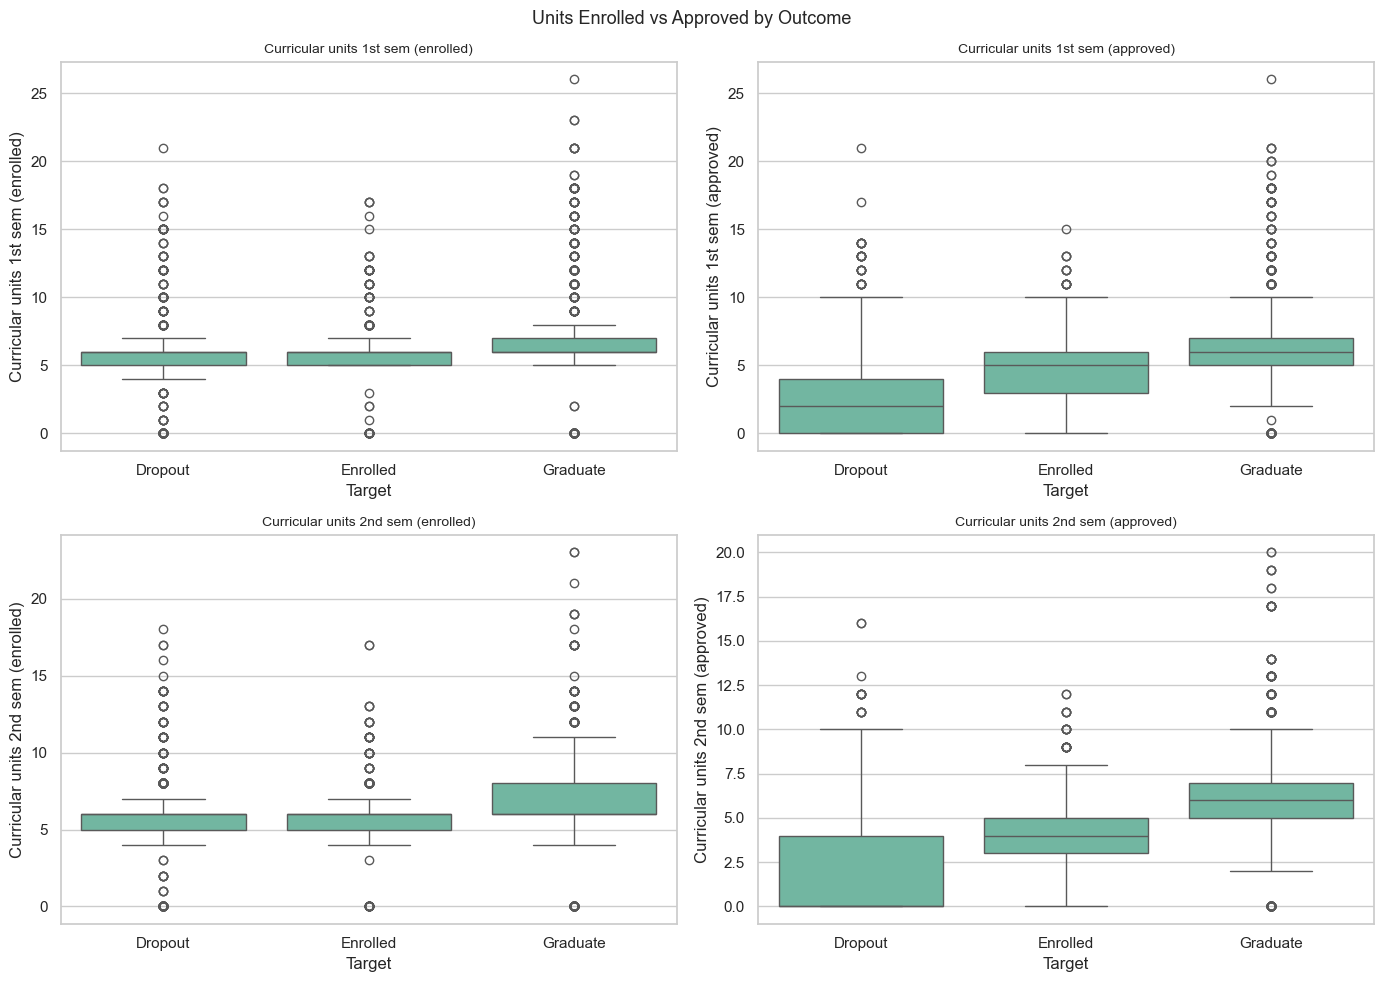

In [23]:
# Compare units enrolled vs approved — a large gap signals struggling students
unit_pairs = [
    ('Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (approved)'),
    ('Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row, (enrolled, approved) in enumerate(unit_pairs):
    sns.boxplot(data=df, x='Target', y=enrolled, ax=axes[row][0],
                order=['Dropout', 'Enrolled', 'Graduate'])
    axes[row][0].set_title(enrolled, fontsize=10)
    sns.boxplot(data=df, x='Target', y=approved, ax=axes[row][1],
                order=['Dropout', 'Enrolled', 'Graduate'])
    axes[row][1].set_title(approved, fontsize=10)

plt.suptitle('Units Enrolled vs Approved by Outcome', fontsize=13)
plt.tight_layout()
plt.savefig('units_enrolled_vs_approved.png', dpi=150, bbox_inches='tight')
plt.show()

### Engineer the approval ratio feature

In [24]:
# Approval ratio = approved / enrolled. Avoid divide-by-zero with np.where.
for sem in ['1st', '2nd']:
    enrolled_col = f'Curricular units {sem} sem (enrolled)'
    approved_col = f'Curricular units {sem} sem (approved)'
    ratio_col = f'Approval ratio {sem} sem'
    df[ratio_col] = np.where(
        df[enrolled_col] > 0,
        df[approved_col] / df[enrolled_col],
        0
    )

# Mean approval ratio per outcome
ratio_summary = df.groupby('Target')[['Approval ratio 1st sem', 'Approval ratio 2nd sem']].mean()
print('Mean approval ratio by outcome:')
print(ratio_summary.round(3))

Mean approval ratio by outcome:
          Approval ratio 1st sem  Approval ratio 2nd sem
Target                                                  
Dropout                    0.384                   0.293
Enrolled                   0.688                   0.649
Graduate                   0.903                   0.900


### Visualise the approval ratio

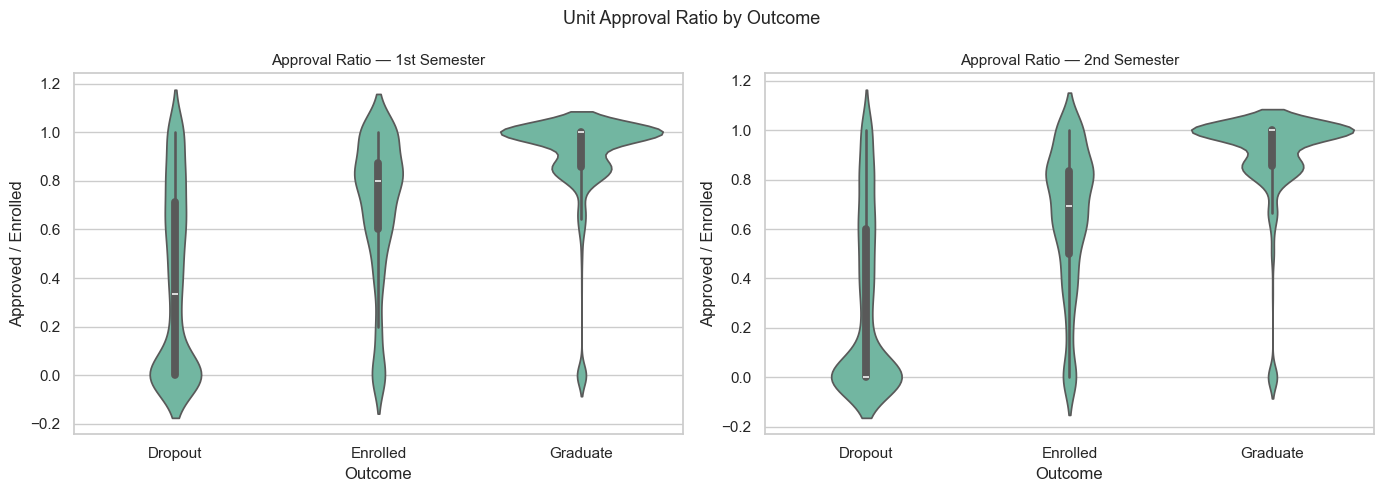

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, sem in enumerate(['1st', '2nd']):
    sns.violinplot(data=df, x='Target', y=f'Approval ratio {sem} sem', ax=axes[i],
                   order=['Dropout', 'Enrolled', 'Graduate'])
    axes[i].set_title(f'Approval Ratio — {sem} Semester', fontsize=11)
    axes[i].set_xlabel('Outcome')
    axes[i].set_ylabel('Approved / Enrolled')

plt.suptitle('Unit Approval Ratio by Outcome', fontsize=13)
plt.tight_layout()
plt.savefig('approval_ratio_by_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

### Sem 1 → Sem 2 grade trajectory (scatter)

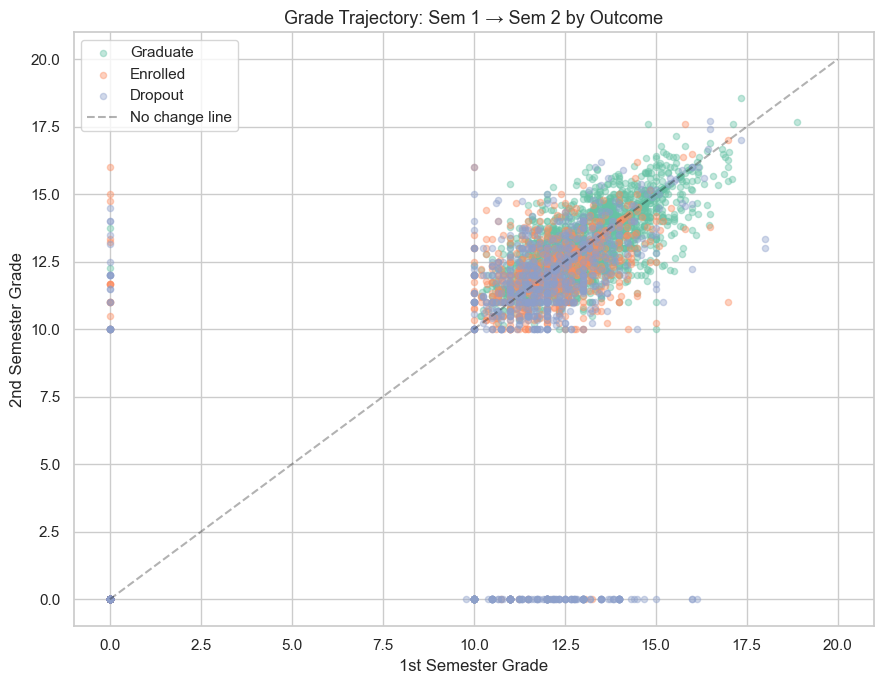

In [26]:
# How do students move from sem 1 to sem 2? Color by outcome.
plt.figure(figsize=(9, 7))
for outcome in ['Graduate', 'Enrolled', 'Dropout']:
    subset = df[df['Target'] == outcome]
    plt.scatter(subset['Curricular units 1st sem (grade)'],
                subset['Curricular units 2nd sem (grade)'],
                alpha=0.4, label=outcome, s=20)

plt.plot([0, 20], [0, 20], 'k--', alpha=0.3, label='No change line')
plt.xlabel('1st Semester Grade')
plt.ylabel('2nd Semester Grade')
plt.title('Grade Trajectory: Sem 1 → Sem 2 by Outcome', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('grade_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

### Summary stats table for your write-up

In [27]:
academic_cols = [
    'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)',
    'Approval ratio 1st sem', 'Approval ratio 2nd sem'
]
summary = df.groupby('Target')[academic_cols].mean().round(2).T
print('Mean academic metrics by outcome:')
print(summary)

Mean academic metrics by outcome:
Target                               Dropout  Enrolled  Graduate
Curricular units 1st sem (grade)        7.26     11.13     12.64
Curricular units 2nd sem (grade)        5.90     11.12     12.70
Curricular units 1st sem (approved)     2.55      4.32      6.23
Curricular units 2nd sem (approved)     1.94      4.06      6.18
Approval ratio 1st sem                  0.38      0.69      0.90
Approval ratio 2nd sem                  0.29      0.65      0.90


# Socioeconomic / financial factors

### Outcome rates by financial status (the headline charts)

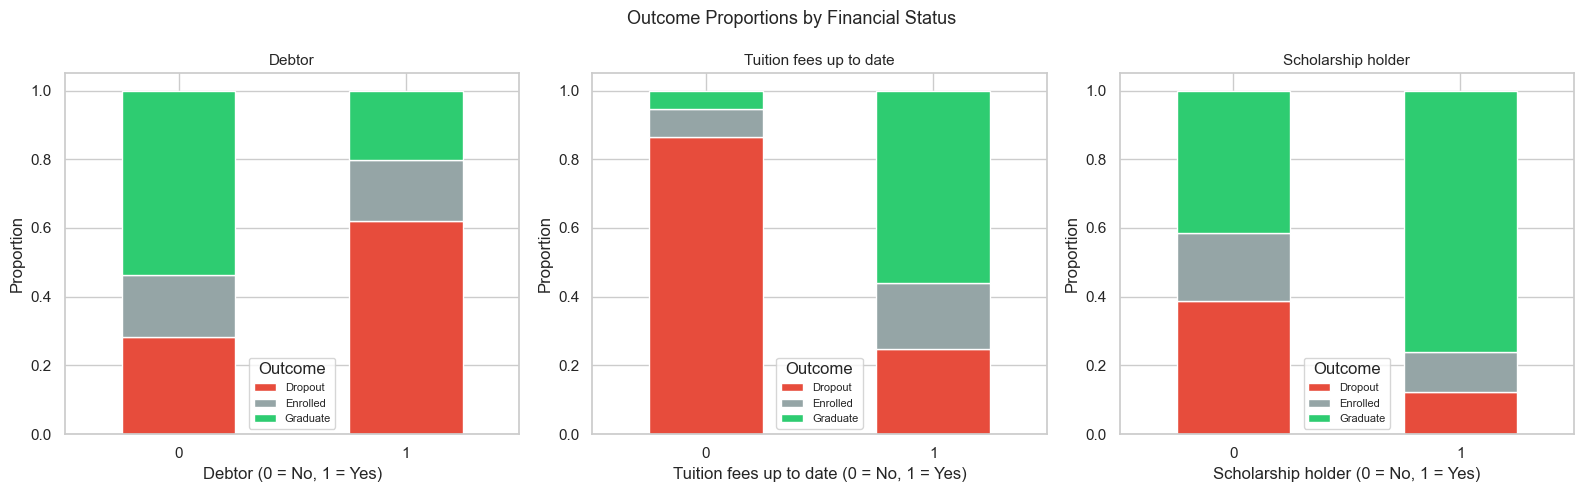

In [28]:
# Binary financial features — show outcome proportions within each category
financial_features = ['Debtor', 'Tuition fees up to date', 'Scholarship holder']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, feat in enumerate(financial_features):
    # Proportion of each outcome within each category value (0/1)
    prop = (df.groupby(feat)['Target']
              .value_counts(normalize=True)
              .unstack()
              .reindex(columns=['Dropout', 'Enrolled', 'Graduate']))
    prop.plot(kind='bar', stacked=True, ax=axes[i],
              color=['#e74c3c', '#95a5a6', '#2ecc71'], edgecolor='white')
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel(f'{feat} (0 = No, 1 = Yes)')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Outcome', fontsize=8)

plt.suptitle('Outcome Proportions by Financial Status', fontsize=13)
plt.tight_layout()
plt.savefig('outcome_by_financial_status.png', dpi=150, bbox_inches='tight')
plt.show()

### Quantify the dropout rates in a table

In [29]:
# Exact dropout rate for each financial category — clean numbers for your slides
for feat in financial_features:
    rates = df.groupby(feat)['Target'].value_counts(normalize=True).unstack()
    print(f"\n--- Dropout rate by {feat} ---")
    print((rates['Dropout'] * 100).round(1).astype(str) + '%')


--- Dropout rate by Debtor ---
Debtor
0    28.3%
1    62.0%
Name: Dropout, dtype: object

--- Dropout rate by Tuition fees up to date ---
Tuition fees up to date
0    86.6%
1    24.7%
Name: Dropout, dtype: object

--- Dropout rate by Scholarship holder ---
Scholarship holder
0    38.7%
1    12.2%
Name: Dropout, dtype: object


### Tuition status is often the strongest single predictor

In [30]:
# Cross-tab of tuition status vs outcome with counts
tuition_crosstab = pd.crosstab(
    df['Tuition fees up to date'],
    df['Target'],
    margins=True
)
print('Tuition fees up to date vs Outcome (counts):')
print(tuition_crosstab)

# Same as percentages within each tuition group
print('\nAs row percentages:')
print((pd.crosstab(df['Tuition fees up to date'], df['Target'], normalize='index') * 100).round(1))

Tuition fees up to date vs Outcome (counts):
Target                   Dropout  Enrolled  Graduate   All
Tuition fees up to date                                   
0                            457        42        29   528
1                            964       752      2180  3896
All                         1421       794      2209  4424

As row percentages:
Target                   Dropout  Enrolled  Graduate
Tuition fees up to date                             
0                           86.6       8.0       5.5
1                           24.7      19.3      56.0


### Macroeconomic context (Unemployment, Inflation, GDP)

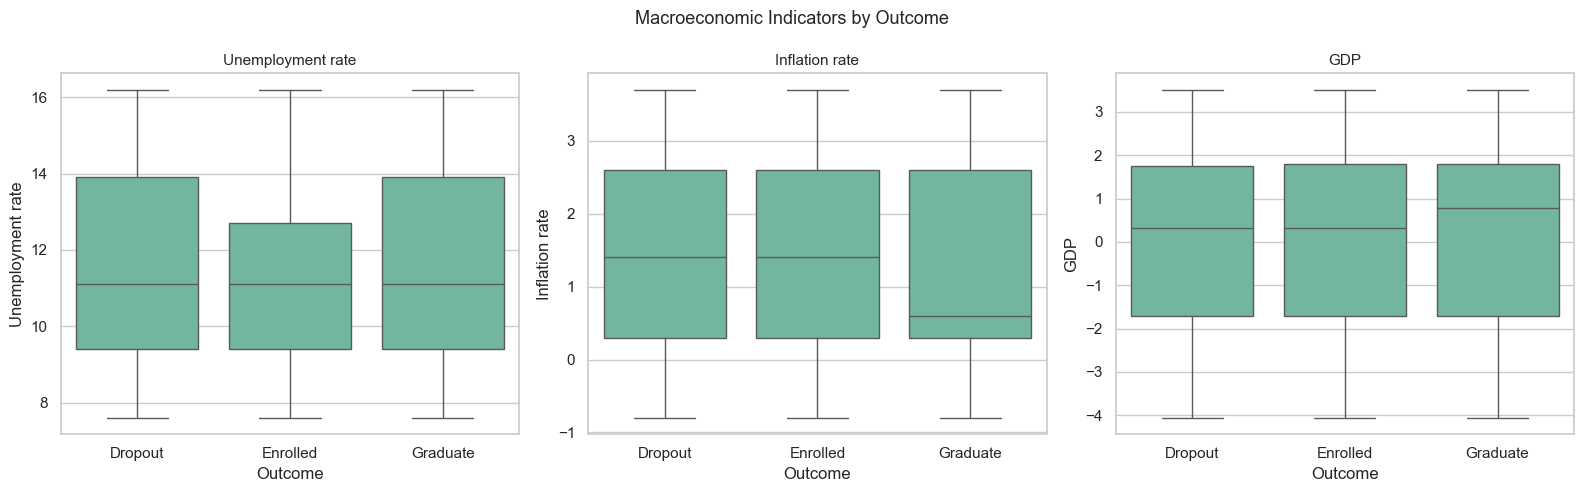

In [31]:
# These are continuous economic indicators tied to enrollment year
macro_features = ['Unemployment rate', 'Inflation rate', 'GDP']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, feat in enumerate(macro_features):
    sns.boxplot(data=df, x='Target', y=feat, ax=axes[i],
                order=['Dropout', 'Enrolled', 'Graduate'])
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Outcome')

plt.suptitle('Macroeconomic Indicators by Outcome', fontsize=13)
plt.tight_layout()
plt.savefig('macro_by_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

### Combined financial risk view

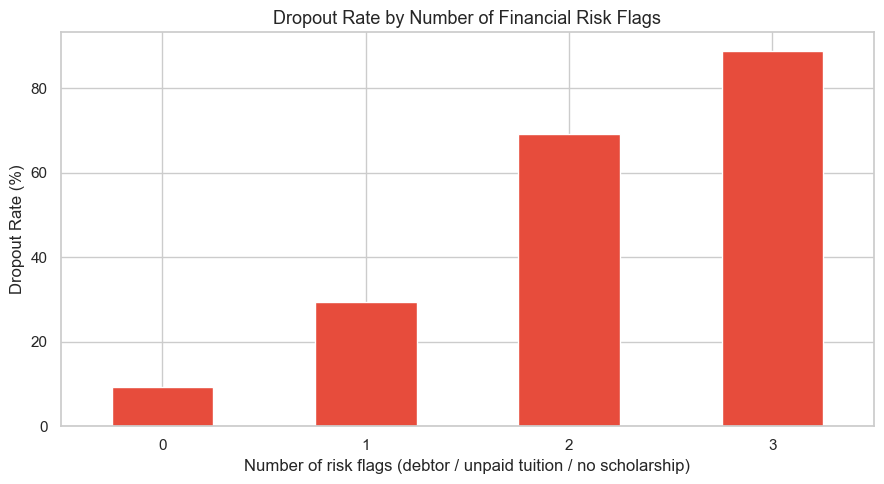

Dropout rate by financial risk flag count:
Financial risk flags
0     9.3%
1    29.3%
2    69.2%
3    88.8%
Name: Dropout, dtype: object


In [32]:
# How does dropout rate stack when financial risk factors combine?
df['Financial risk flags'] = (
    (df['Debtor'] == 1).astype(int) +
    (df['Tuition fees up to date'] == 0).astype(int) +
    (df['Scholarship holder'] == 0).astype(int)
)

risk_dropout = (df.groupby('Financial risk flags')['Target']
                  .value_counts(normalize=True)
                  .unstack()['Dropout'] * 100).round(1)

plt.figure(figsize=(9, 5))
risk_dropout.plot(kind='bar', color='#e74c3c', edgecolor='white')
plt.title('Dropout Rate by Number of Financial Risk Flags', fontsize=13)
plt.xlabel('Number of risk flags (debtor / unpaid tuition / no scholarship)')
plt.ylabel('Dropout Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('financial_risk_stacking.png', dpi=150, bbox_inches='tight')
plt.show()

print('Dropout rate by financial risk flag count:')
print(risk_dropout.astype(str) + '%')

### Correlation view against target

/var/folders/hk/svxlhg9x51j4t3tpg3zjg__00000gn/T/ipykernel_1869/1794615787.py:15: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/hk/svxlhg9x51j4t3tpg3zjg__00000gn/T/ipykernel_1869/1794615787.py:16: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  plt.savefig('correlation_with_dropout.png', dpi=150, bbox_inches='tight')
/opt/anaconda3/envs/tfenv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


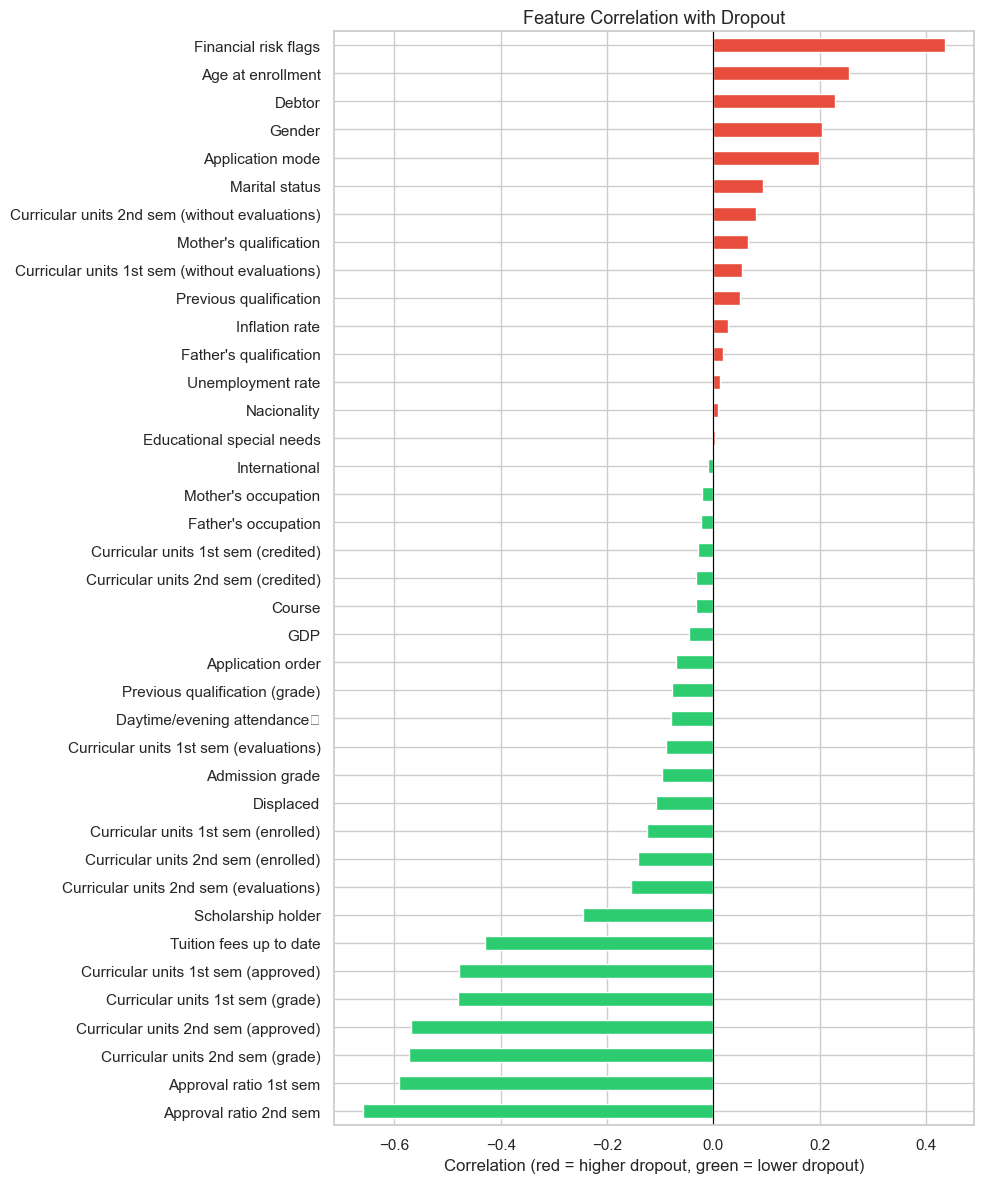

Features most associated with dropout:
Mother's qualification                            0.065
Curricular units 2nd sem (without evaluations)    0.080
Marital status                                    0.094
Application mode                                  0.198
Gender                                            0.204
Debtor                                            0.229
Age at enrollment                                 0.254
Financial risk flags                              0.435
Name: Is dropout, dtype: float64

Features most associated with NOT dropping out:
Approval ratio 2nd sem                -0.659
Approval ratio 1st sem                -0.591
Curricular units 2nd sem (grade)      -0.572
Curricular units 2nd sem (approved)   -0.570
Curricular units 1st sem (grade)      -0.481
Curricular units 1st sem (approved)   -0.479
Tuition fees up to date               -0.429
Scholarship holder                    -0.245
Name: Is dropout, dtype: float64


In [35]:
# Create a binary dropout indicator for correlation analysis
df['Is dropout'] = (df['Target'] == 'Dropout').astype(int)

# Correlate all numeric features against the dropout flag
numeric_df = df.select_dtypes(include=[np.number])
target_corr = numeric_df.corr()['Is dropout'].drop('Is dropout')
target_corr = target_corr.sort_values()

plt.figure(figsize=(10, 12))
colors = ['#2ecc71' if v < 0 else '#e74c3c' for v in target_corr.values]
target_corr.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Correlation with Dropout', fontsize=13)
plt.xlabel('Correlation (red = higher dropout, green = lower dropout)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('correlation_with_dropout.png', dpi=150, bbox_inches='tight')
plt.show()

print('Features most associated with dropout:')
print(target_corr.tail(8).round(3))   # strongest positive
print('\nFeatures most associated with NOT dropping out:')
print(target_corr.head(8).round(3))   # strongest negative

# Demographics, including parent information

### Age at enrollment (the one continuous demographic)

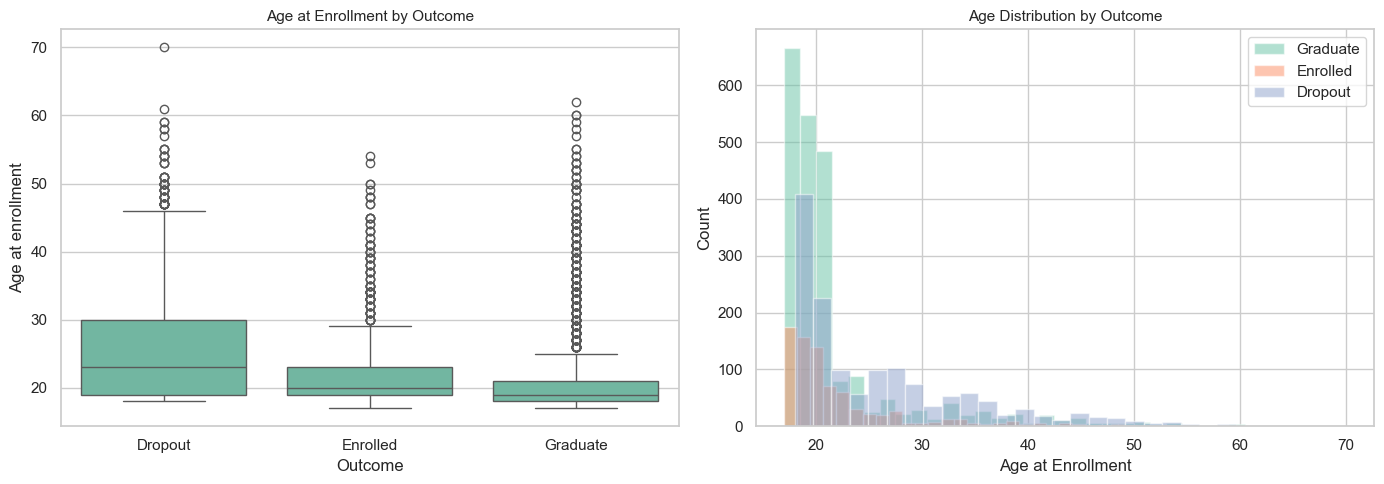

Median age by outcome:
Target
Dropout     23.0
Enrolled    20.0
Graduate    19.0
Name: Age at enrollment, dtype: float64
Mean age by outcome:
Target
Dropout     26.068966
Enrolled    22.369018
Graduate    21.783612
Name: Age at enrollment, dtype: float64


In [36]:
# Age showed up as a dropout correlate — look at the full distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot by outcome
sns.boxplot(data=df, x='Target', y='Age at enrollment', ax=axes[0],
            order=['Dropout', 'Enrolled', 'Graduate'])
axes[0].set_title('Age at Enrollment by Outcome', fontsize=11)
axes[0].set_xlabel('Outcome')

# Overlaid histograms
for outcome in ['Graduate', 'Enrolled', 'Dropout']:
    subset = df[df['Target'] == outcome]['Age at enrollment']
    axes[1].hist(subset, bins=30, alpha=0.5, label=outcome)
axes[1].set_title('Age Distribution by Outcome', fontsize=11)
axes[1].set_xlabel('Age at Enrollment')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('age_by_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

print('Median age by outcome:')
print(df.groupby('Target')['Age at enrollment'].median())

print('Mean age by outcome:')
print(df.groupby('Target')['Age at enrollment'].mean())

### Binary demographic flags

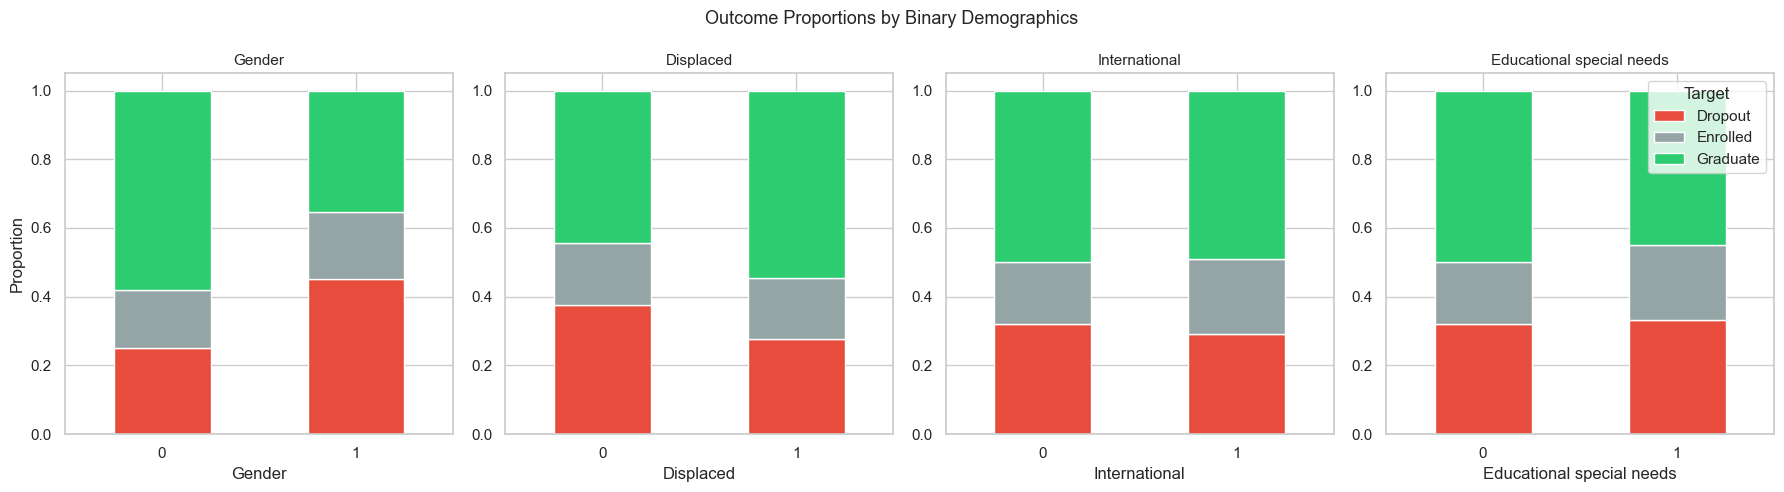

In [56]:
# Binary demographics — outcome proportions within each
binary_demos = ['Gender', 'Displaced', 'International', 'Educational special needs']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, feat in enumerate(binary_demos):
    prop = (df.groupby(feat)['Target']
              .value_counts(normalize=True)
              .unstack()
              .reindex(columns=['Dropout', 'Enrolled', 'Graduate']))
    prop.plot(kind='bar', stacked=True, ax=axes[i],
              color=['#e74c3c', '#95a5a6', '#2ecc71'], edgecolor='white', legend=(i==3))
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Proportion' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Outcome Proportions by Binary Demographics', fontsize=13)
plt.tight_layout()
plt.savefig('binary_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

There are more women than men that have 2+ financial risk flags. However, the proportion of men who drop out is larger.

### Marital status (multi-category)

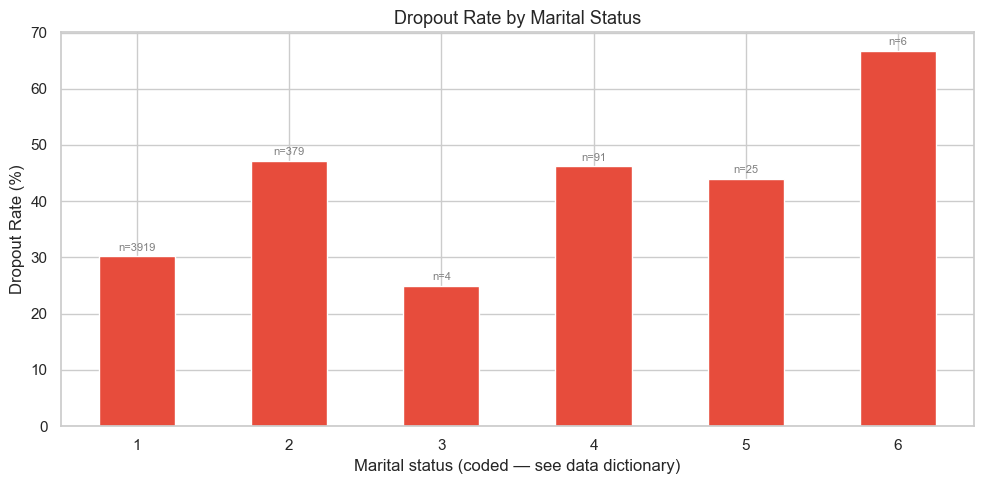

In [64]:
# Marital status has several categories — dropout rate per category
marital_dropout = (df.groupby('Marital status')['Target']
                     .value_counts(normalize=True)
                     .unstack()['Dropout'] * 100).round(1)#.sort_values(ascending=False)

marital_counts = df['Marital status'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
marital_dropout.plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='white')
ax.set_title('Dropout Rate by Marital Status', fontsize=13)
ax.set_xlabel('Marital status (coded — see data dictionary)')
ax.set_ylabel('Dropout Rate (%)')
ax.tick_params(axis='x', rotation=0)

# Annotate with group sizes so small categories are obvious
for i, code in enumerate(marital_dropout.index):
    ax.text(i, marital_dropout[code] + 1, f'n={marital_counts[code]}',
            ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('marital_status_dropout.png', dpi=150, bbox_inches='tight')
plt.show()

1 – single 2 – married 3 – widower 4 – divorced 5 – facto union 6 – legally separated

### Parental qualification levels

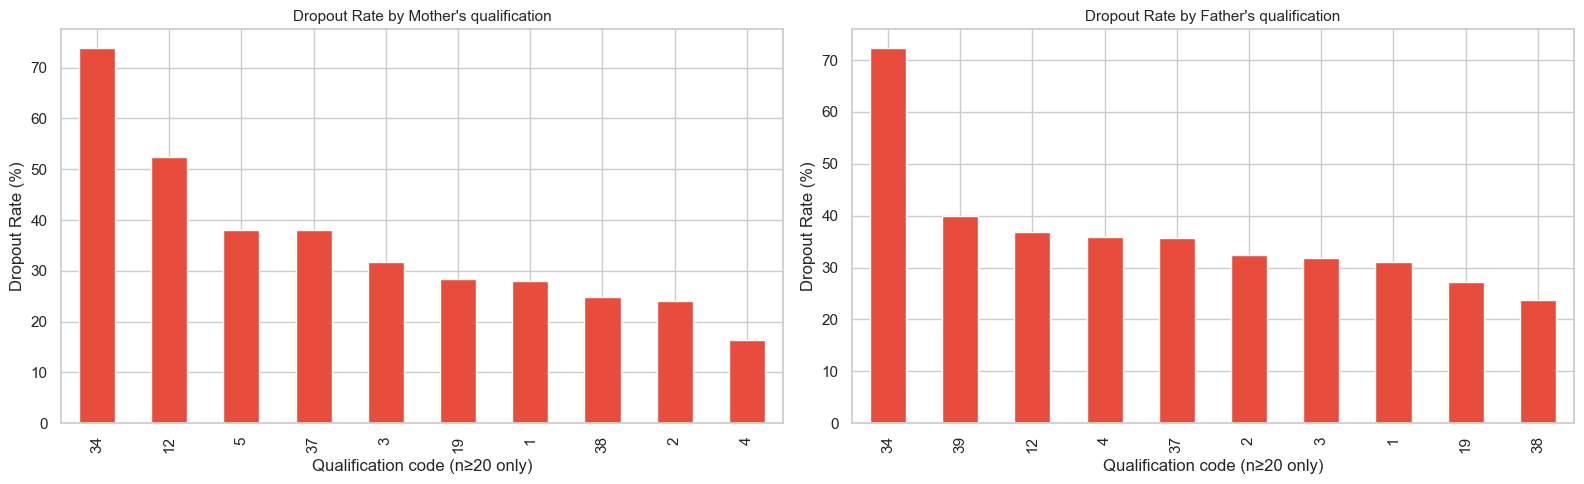

In [65]:
# Parental qualifications are high-cardinality — dropout rate per level, ordered
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i, parent in enumerate(["Mother's qualification", "Father's qualification"]):
    rate = (df.groupby(parent)['Target']
              .value_counts(normalize=True)
              .unstack()['Dropout'] * 100)
    counts = df[parent].value_counts()
    # Only show categories with a meaningful sample (>= 20 students)
    valid = counts[counts >= 20].index
    rate = rate[rate.index.isin(valid)].sort_values(ascending=False)
    rate.plot(kind='bar', ax=axes[i], color='#e74c3c', edgecolor='white')
    axes[i].set_title(f'Dropout Rate by {parent}', fontsize=11)
    axes[i].set_xlabel('Qualification code (n≥20 only)')
    axes[i].set_ylabel('Dropout Rate (%)')

plt.tight_layout()
plt.savefig('parental_qualification.png', dpi=150, bbox_inches='tight')
plt.show()

### Parental occupation

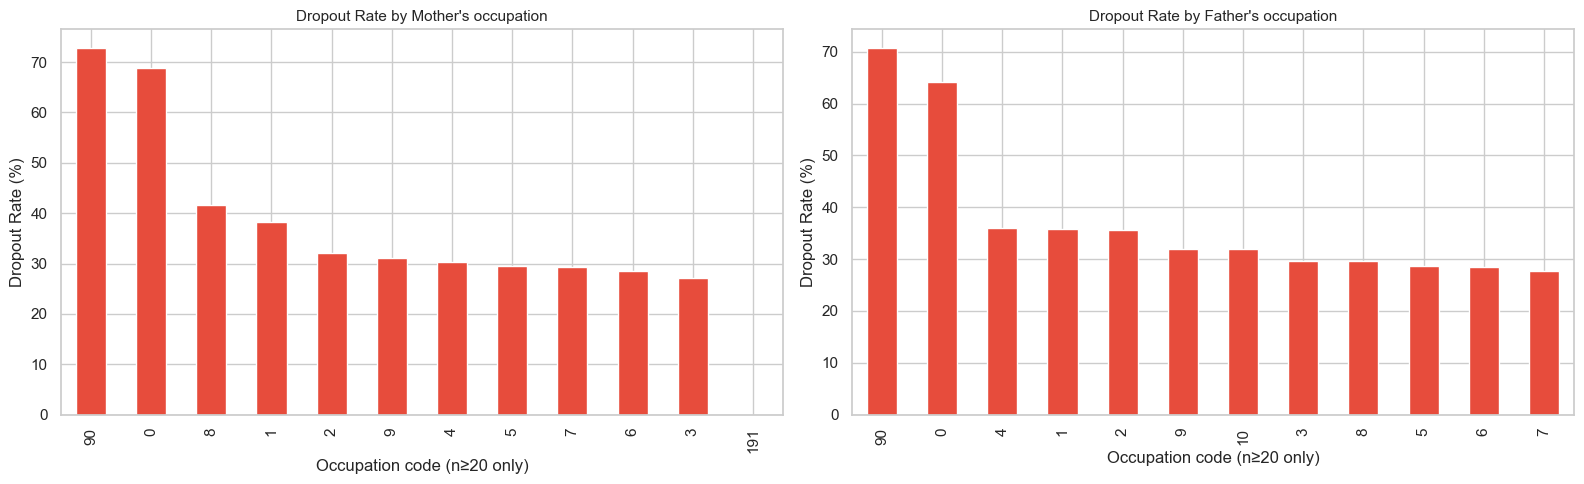

In [66]:
# Same approach for occupations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i, parent in enumerate(["Mother's occupation", "Father's occupation"]):
    rate = (df.groupby(parent)['Target']
              .value_counts(normalize=True)
              .unstack()['Dropout'] * 100)
    counts = df[parent].value_counts()
    valid = counts[counts >= 20].index
    rate = rate[rate.index.isin(valid)].sort_values(ascending=False)
    rate.plot(kind='bar', ax=axes[i], color='#e74c3c', edgecolor='white')
    axes[i].set_title(f'Dropout Rate by {parent}', fontsize=11)
    axes[i].set_xlabel('Occupation code (n≥20 only)')
    axes[i].set_ylabel('Dropout Rate (%)')

plt.tight_layout()
plt.savefig('parental_occupation.png', dpi=150, bbox_inches='tight')
plt.show()

### Age binned, since age was the strongest demographic signal

/var/folders/hk/svxlhg9x51j4t3tpg3zjg__00000gn/T/ipykernel_1869/1898793999.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_dropout = (df.groupby('Age group')['Target']


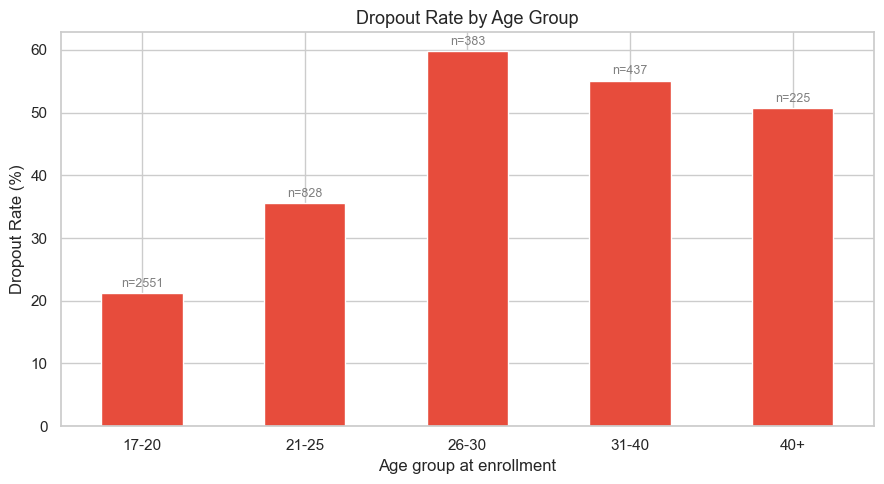

In [68]:
# Bin age into meaningful groups
age_bins = [16, 20, 25, 30, 40, 70]
age_labels = ['17-20', '21-25', '26-30', '31-40', '40+']
df['Age group'] = pd.cut(df['Age at enrollment'], bins=age_bins, labels=age_labels)

age_dropout = (df.groupby('Age group')['Target']
                 .value_counts(normalize=True)
                 .unstack()['Dropout'] * 100).round(1)

# Group sizes for annotation
age_counts = df['Age group'].value_counts().reindex(age_labels)

plt.figure(figsize=(9, 5))
ax = age_dropout.plot(kind='bar', color='#e74c3c', edgecolor='white')
plt.title('Dropout Rate by Age Group', fontsize=13)
plt.xlabel('Age group at enrollment')
plt.ylabel('Dropout Rate (%)')
plt.xticks(rotation=0)

# Annotate n= on top of each bar
for i, label in enumerate(age_labels):
    plt.text(i, age_dropout[label] + 1, f'n={age_counts[label]}',
             ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('dropout_by_age_group.png', dpi=150, bbox_inches='tight')
plt.show()

# Admission and Entry characteristics

### Entry grades vs outcome

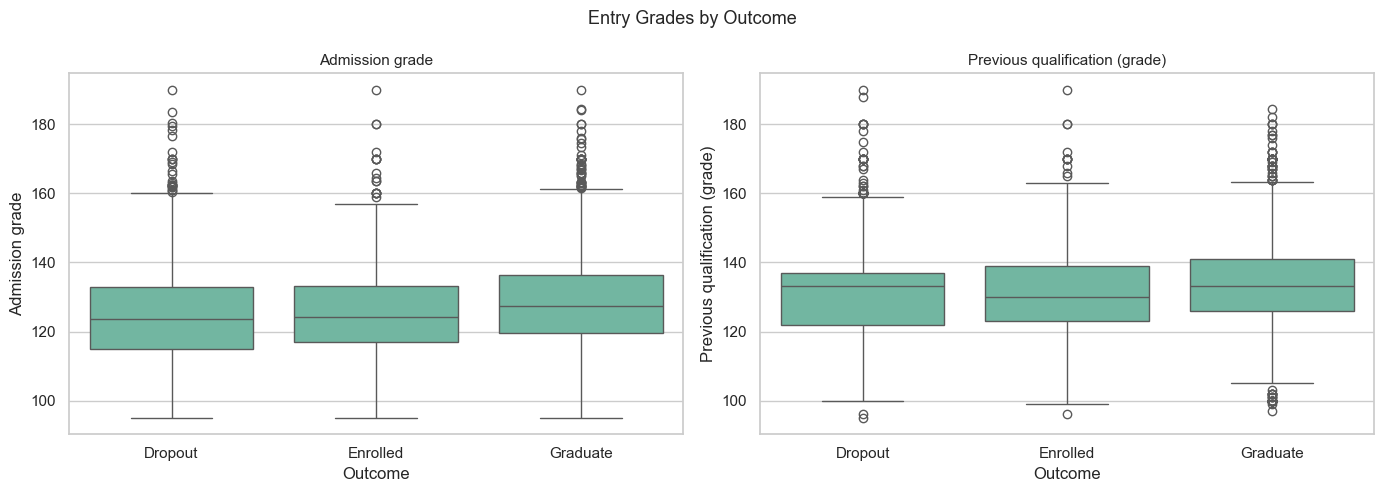

Median entry grades by outcome:
          Admission grade  Previous qualification (grade)
Target                                                   
Dropout             123.6                           133.1
Enrolled            124.1                           130.0
Graduate            127.4                           133.1


In [69]:
# The two continuous entry features: admission grade and prior qualification grade
entry_grades = ['Admission grade', 'Previous qualification (grade)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, feat in enumerate(entry_grades):
    sns.boxplot(data=df, x='Target', y=feat, ax=axes[i],
                order=['Dropout', 'Enrolled', 'Graduate'])
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Outcome')

plt.suptitle('Entry Grades by Outcome', fontsize=13)
plt.tight_layout()
plt.savefig('entry_grades_by_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

print('Median entry grades by outcome:')
print(df.groupby('Target')[entry_grades].median())

### Dropout rate by Course (the key chart)

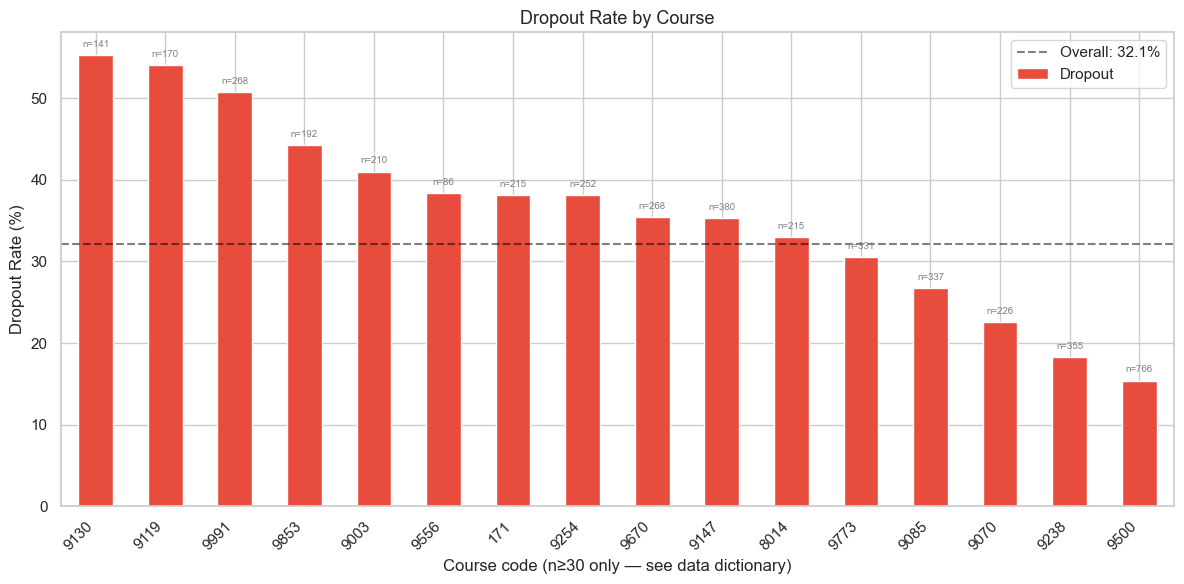

In [70]:
# Course is high-cardinality — dropout rate per course, filtered for sample size
course_dropout = (df.groupby('Course')['Target']
                    .value_counts(normalize=True)
                    .unstack()['Dropout'] * 100).round(1)
course_counts = df['Course'].value_counts()

# Keep courses with a meaningful sample
valid_courses = course_counts[course_counts >= 30].index
course_dropout = course_dropout[course_dropout.index.isin(valid_courses)].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
ax = course_dropout.plot(kind='bar', color='#e74c3c', edgecolor='white')
plt.title('Dropout Rate by Course', fontsize=13)
plt.xlabel('Course code (n≥30 only — see data dictionary)')
plt.ylabel('Dropout Rate (%)')
plt.xticks(rotation=45, ha='right')

# Annotate group sizes
for i, code in enumerate(course_dropout.index):
    plt.text(i, course_dropout[code] + 1, f'n={course_counts[code]}',
             ha='center', fontsize=7, color='gray')

# Reference line at overall dropout rate
overall_dropout = (df['Target'] == 'Dropout').mean() * 100
plt.axhline(overall_dropout, color='black', linestyle='--', alpha=0.5,
            label=f'Overall: {overall_dropout:.1f}%')
plt.legend()

plt.tight_layout()
plt.savefig('dropout_by_course.png', dpi=150, bbox_inches='tight')
plt.show()

9130 - Equinculture, 9119 - Informatics Engineering, 9991 - Management (evening attendance), 9853 - Basic Education, 9003 - Agronomy:

Course matters slightly???

### Application mode

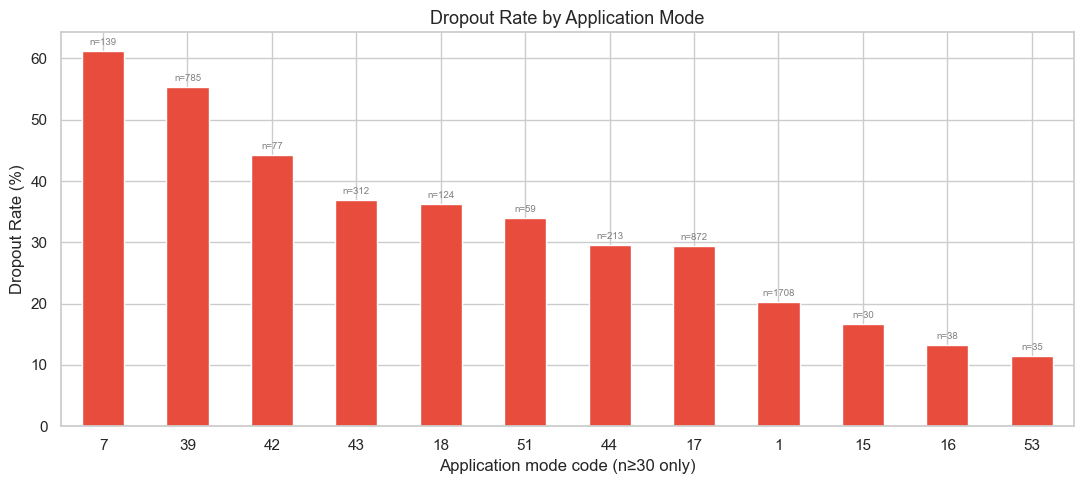

In [71]:
# How students applied (e.g. 1st phase, transfer, over-23, etc.)
appmode_dropout = (df.groupby('Application mode')['Target']
                     .value_counts(normalize=True)
                     .unstack()['Dropout'] * 100).round(1)
appmode_counts = df['Application mode'].value_counts()

valid_modes = appmode_counts[appmode_counts >= 30].index
appmode_dropout = appmode_dropout[appmode_dropout.index.isin(valid_modes)].sort_values(ascending=False)

plt.figure(figsize=(11, 5))
appmode_dropout.plot(kind='bar', color='#e74c3c', edgecolor='white')
plt.title('Dropout Rate by Application Mode', fontsize=13)
plt.xlabel('Application mode code (n≥30 only)')
plt.ylabel('Dropout Rate (%)')
plt.xticks(rotation=0)

for i, code in enumerate(appmode_dropout.index):
    plt.text(i, appmode_dropout[code] + 1, f'n={appmode_counts[code]}',
             ha='center', fontsize=7, color='gray')

plt.tight_layout()
plt.savefig('dropout_by_application_mode.png', dpi=150, bbox_inches='tight')
plt.show()

Application code 39 means over 23 years old, we can see that age somewhat plays a role

### Application order

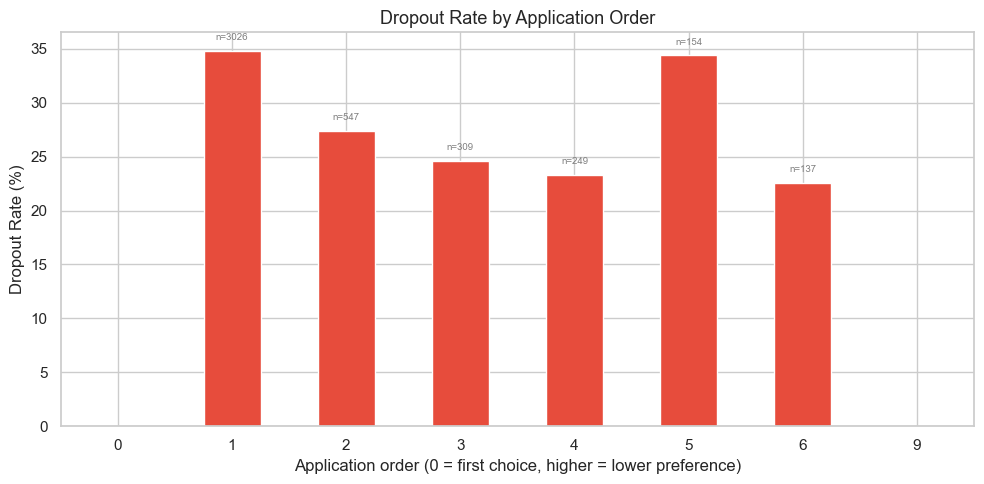

In [72]:
# Application order: was this their 1st choice (0) or a fallback?
apporder_dropout = (df.groupby('Application order')['Target']
                      .value_counts(normalize=True)
                      .unstack()['Dropout'] * 100).round(1)
apporder_counts = df['Application order'].value_counts()

plt.figure(figsize=(10, 5))
apporder_dropout.plot(kind='bar', color='#e74c3c', edgecolor='white')
plt.title('Dropout Rate by Application Order', fontsize=13)
plt.xlabel('Application order (0 = first choice, higher = lower preference)')
plt.ylabel('Dropout Rate (%)')
plt.xticks(rotation=0)

for i, code in enumerate(sorted(apporder_dropout.index)):
    plt.text(i, apporder_dropout[code] + 1, f'n={apporder_counts[code]}',
             ha='center', fontsize=7, color='gray')

plt.tight_layout()
plt.savefig('dropout_by_application_order.png', dpi=150, bbox_inches='tight')
plt.show()

### Daytime vs evening attendance

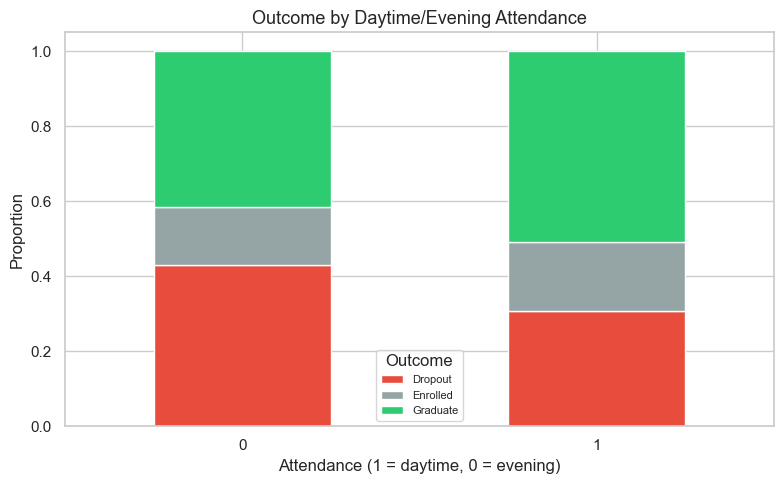

In [73]:
# Evening students are often working adults — does mode of attendance matter?
attendance_col = [c for c in df.columns if 'attendance' in c.lower()][0]  # handles trailing whitespace in name

prop = (df.groupby(attendance_col)['Target']
          .value_counts(normalize=True)
          .unstack()
          .reindex(columns=['Dropout', 'Enrolled', 'Graduate']))

prop.plot(kind='bar', stacked=True, figsize=(8, 5),
          color=['#e74c3c', '#95a5a6', '#2ecc71'], edgecolor='white')
plt.title('Outcome by Daytime/Evening Attendance', fontsize=13)
plt.xlabel('Attendance (1 = daytime, 0 = evening)')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Outcome', fontsize=8)
plt.tight_layout()
plt.savefig('dropout_by_attendance.png', dpi=150, bbox_inches='tight')
plt.show()